<a href="https://colab.research.google.com/github/sAI-2025/Intelligent-Customer-Signal-Detector/blob/main/telco_churn_score_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Churn Score Regression (0–100)

End-to-end notebook: EDA, feature selection, encoding, correlation, collinearity, feature importance, XGBoost regression with tuning.

In [195]:
# ============================================================
# 1. Imports & basic setup
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [196]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [197]:
# ============================================================
# 2. Load data
# ============================================================
# Adjust path if needed (this assumes Telco_customer_churn.csv is in the working dir)
df = pd.read_csv('/content/drive/MyDrive/FirstSource/Telco_customer_final_sample.csv')


In [198]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()

In [199]:

print('Shape:', df.shape)
df.head()

Shape: (2000, 57)


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn,churn_rate,churn_score_target,cltv,churn_reason,count,country,state,city,zip_code,lat_long,latitude,longitude,age,under_30,married,referred_a_friend,number_of_referrals,offer,avg_monthly_long_distance_charges,avg_monthly_gb_download,streaming_music,premium_tech_support,unlimited_data,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status,churn_score_1,churn_category,satisfaction_level,service_count,open_issue_count,close_issue_count,support_interaction_count,resolution_status_open_closed
0,4795-UXVCJ,Male,0,No,No,26,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),19.8,457.30,No,0,77,5823,NaN,1,United States,California,Gonzales,93926,"36.52588, -121.396719",36.525880,-121.396719,63,No,No,No,0,Offer C,45.70,0,No,No,No,0.00,0,1188.20,1645.50,Stayed,77,0,Medium,1,7,1,8,Resolved
1,1915-IOFGU,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Electronic check,70.5,70.50,Yes,1,90,4123,Competitor offered higher download speeds,1,United States,California,Keene,93531,"35.214982, -118.59049",35.214982,-118.590490,53,No,No,No,0,None,41.39,3,No,No,Yes,0.00,0,41.39,111.89,Churned,90,Competitor,Low,1,9,0,9,Resolved
2,9680-NIAUV,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Credit card (automatic),109.7,8129.30,No,0,74,5945,NaN,1,United States,California,West Hills,91307,"34.199787, -118.68493",34.199787,-118.684930,42,No,Yes,Yes,7,Offer A,18.66,3,Yes,No,Yes,0.00,0,1343.52,9472.82,Stayed,74,0,High,1,7,0,7,NotResolved
3,5519-NPHVG,Female,0,No,No,12,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.2,1046.10,Yes,1,73,3975,Price too high,1,United States,California,Klamath River,96050,"41.816595, -122.948287",41.816595,-122.948287,53,No,No,No,0,None,12.75,24,Yes,No,No,7.39,120,153.00,1311.71,Churned,73,Price,Medium,1,7,1,8,Resolved
4,9513-DXHDA,Male,0,No,No,27,Yes,No,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,No,Electronic check,81.7,2212.55,No,0,39,2445,NaN,1,United States,California,Auburn,95603,"38.912881, -121.082766",38.912881,-121.082766,58,No,No,No,0,None,49.25,4,Yes,Yes,Yes,0.00,0,1329.75,3542.30,Stayed,39,0,High,1,0,4,4,Resolved


In [200]:
# ============================================================
# 3. Initial info & basic description
# ============================================================
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 57 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        2000 non-null   object 
 1   gender                             2000 non-null   object 
 2   senior_citizen                     2000 non-null   int64  
 3   partner                            2000 non-null   object 
 4   dependents                         2000 non-null   object 
 5   tenure_months                      2000 non-null   int64  
 6   phone_service                      2000 non-null   object 
 7   multiple_lines                     2000 non-null   object 
 8   internet_service                   2000 non-null   object 
 9   online_security                    2000 non-null   object 
 10  online_backup                      2000 non-null   object 
 11  device_protection                  2000 non-null   objec

In [201]:
print('Basic numeric description:')
display(df.describe(include=[np.number]))



Basic numeric description:


,senior_citizen,tenure_months,monthly_charges,total_charges,churn_rate,churn_score_target,cltv,count,zip_code,latitude,longitude,age,number_of_referrals,avg_monthly_long_distance_charges,avg_monthly_gb_download,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,churn_score_1,service_count,open_issue_count,close_issue_count,support_interaction_count
count,2000.000000,2000.000000,2000.000000,1997.000000,2000.000000,2000.00000,2000.000000,2000.0,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0,2000.000000,2000.000000,2000.000000
mean,0.193000,27.512500,67.370725,2016.131873,0.500000,66.05500,4303.652500,1.0,93524.734000,36.252167,-119.754465,47.710000,1.545000,22.574355,20.522000,1.681520,7.240000,621.757265,2641.018920,65.673500,1.0,5.132500,1.839000,6.971500
std,0.394752,24.291519,28.773218,2196.289027,0.500125,21.89065,1190.208449,0.0,1844.876604,2.462842,2.142090,16.994773,2.708254,15.448696,19.280933,7.055814,25.876963,784.638039,2783.000933,21.306029,0.0,3.439456,2.041118,1.891157
min,0.000000,0.000000,18.400000,18.850000,0.000000,5.00000,2007.000000,1.0,90001.000000,32.555828,-124.301372,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.400000,5.000000,1.0,0.000000,0.000000,1.000000
25%,0.000000,5.000000,45.350000,259.800000,0.000000,49.00000,3326.750000,1.0,92102.750000,34.031507,-121.795867,33.000000,0.000000,8.910000,6.000000,0.000000,0.000000,42.107500,382.565000,49.000000,1.0,1.000000,0.000000,6.000000
50%,0.000000,20.000000,74.400000,1096.250000,0.500000,70.00000,4409.000000,1.0,93531.000000,36.296851,-119.570130,47.000000,0.000000,22.280000,17.000000,0.000000,0.000000,267.625000,1562.600000,70.000000,1.0,7.000000,1.000000,7.000000
75%,0.000000,49.000000,90.350000,3263.900000,1.000000,82.00000,5295.250000,1.0,95345.250000,38.162689,-118.012080,61.000000,1.000000,36.195000,27.000000,0.000000,0.000000,940.680000,4137.320000,82.000000,1.0,8.000000,3.000000,8.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000,100.00000,6499.000000,1.0,96161.000000,41.950683,-114.192901,80.000000,10.000000,49.980000,85.000000,49.380000,150.000000,3564.000000,11795.780000,96.000000,1.0,10.000000,6.000000,11.000000


In [202]:
df['total_charges'] = df['total_charges'].fillna(df['total_charges'].median())

In [203]:

print('Basic categorical description:')
display(df.describe(include=['object']))

Basic categorical description:


,customer_id,gender,partner,dependents,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,churn,churn_reason,country,state,city,lat_long,under_30,married,referred_a_friend,offer,streaming_music,premium_tech_support,unlimited_data,customer_status,churn_category,satisfaction_level,resolution_status_open_closed
count,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,1000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000
unique,2000,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2,20,1,1,882,1262,2,2,2,6,2,2,2,3,6,3,2
top,9795-VOWON,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No,Attitude of support person,United States,California,Los Angeles,"36.52588, -121.396719",No,No,No,None,No,No,Yes,Churned,0,Low,Resolved
freq,1,1009,1110,1493,1800,952,1015,1149,1035,981,1151,835,849,1299,1257,798,1000,110,2000,2000,85,4,1644,1110,1168,1100,1277,1495,1426,1000,1000,768,1716


In [204]:
# ============================================================
# 4. Nulls and single-unique / high-null columns
#    + drop unnecessary / leakage / high-cardinality features
#    Target: churn_score_1 (0–100)
# ============================================================

# 4.1 Nulls overview
null_counts = df.isna().sum()
null_pct = df.isna().mean() * 100
null_df = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
print('Nulls per column:')
display(null_df.sort_values('null_pct', ascending=False))

Nulls per column:


,null_count,null_pct
churn_reason,1000,50.0
gender,0,0.0
senior_citizen,0,0.0
partner,0,0.0
dependents,0,0.0
tenure_months,0,0.0
phone_service,0,0.0
multiple_lines,0,0.0
customer_id,0,0.0
internet_service,0,0.0


In [205]:
# 4.2 Single-unique columns (constant features)
nunique = df.nunique()
const_cols = list(nunique[nunique == 1].index)
print('Columns with only 1 unique value (constant features):')
print(const_cols)

Columns with only 1 unique value (constant features):
['count', 'country', 'state', 'service_count']


In [206]:
# 4.3 High-null columns (> 30% missing)
high_null_cols = list(null_df[null_df['null_pct'] > 30].index)
print('Columns with >30% missing values:')
print(high_null_cols)

Columns with >30% missing values:
['churn_reason']


In [207]:
# 4.4 Your provided drop list (cleaned and aligned to column names)
drop_cols = [
    # Original leakage / redundant columns
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'premium_tech_support',
    'cltv',
    'churn_reason',
    'customer_status',
    'churn_category',
    'avg_monthly_long_distance_charges',
    'churn',

    # Additional leakage / post-outcome features
    'churn_rate',
    #'churn_score_1',

    # Identifier
    'customer_id',

    # Operational support / resolution
    'open_issue_count',
    'close_issue_count',
    'support_interaction_count',
    'resolution_status_open_closed',

    # Redundant representation
    'under_30',

    # Redundant geographic representation
    'lat_long',
    "churn_score_target",
    # High-cardinality geography
    'city',
    'zip_code',
    'latitude',
    'longitude',

    # Referral / long-distance charge features
    'referred_a_friend',
    'total_long_distance_charges',
]


# 4.5 Drop constant features, high-null features, and explicit drop_cols
cols_to_drop = set(const_cols) | set(high_null_cols) | set(drop_cols)
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
print('Columns that will be dropped:')
print(sorted(cols_to_drop))

df_model = df.drop(columns=cols_to_drop)
print('Shape after dropping:', df_model.shape)
df_model.head()

Columns that will be dropped:
['avg_monthly_long_distance_charges', 'churn', 'churn_category', 'churn_rate', 'churn_reason', 'churn_score_target', 'city', 'close_issue_count', 'cltv', 'count', 'country', 'customer_id', 'customer_status', 'device_protection', 'lat_long', 'latitude', 'longitude', 'online_backup', 'online_security', 'open_issue_count', 'premium_tech_support', 'referred_a_friend', 'resolution_status_open_closed', 'service_count', 'state', 'support_interaction_count', 'tech_support', 'total_long_distance_charges', 'under_30', 'zip_code']
Shape after dropping: (2000, 27)


,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,age,married,number_of_referrals,offer,avg_monthly_gb_download,streaming_music,unlimited_data,total_refunds,total_extra_data_charges,total_revenue,churn_score_1,satisfaction_level
0,Male,0,No,No,26,Yes,No,No,No internet service,No internet service,One year,No,Credit card (automatic),19.8,457.30,63,No,0,Offer C,0,No,No,0.00,0,1645.50,77,Medium
1,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Month-to-month,No,Electronic check,70.5,70.50,53,No,0,None,3,No,Yes,0.00,0,111.89,90,Low
2,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Two year,No,Credit card (automatic),109.7,8129.30,42,Yes,7,Offer A,3,Yes,Yes,0.00,0,9472.82,74,High
3,Female,0,No,No,12,Yes,Yes,Fiber optic,Yes,Yes,Month-to-month,Yes,Electronic check,94.2,1046.10,53,No,0,None,24,Yes,No,7.39,120,1311.71,73,Medium
4,Male,0,No,No,27,Yes,No,DSL,Yes,Yes,One year,No,Electronic check,81.7,2212.55,58,No,0,None,4,Yes,Yes,0.00,0,3542.30,39,High


In [208]:
df = df_model

In [209]:
 # ============================================================
# 1. gender -> ismale
# ============================================================
df['ismale'] = (df['gender'] == 'Male  ').astype(int)
df.drop(columns=['gender'], inplace=True)

# ============================================================
# 2. partner -> ispartner
# ============================================================
df['ispartner'] = (df['partner'] == 'Yes').astype(int)
df.drop(columns=['partner'], inplace=True)

# ============================================================
# 3. dependents -> isdependents
# ============================================================
df['isdependents'] = (df['dependents'] == 'Yes').astype(int)
df.drop(columns=['dependents'], inplace=True)

# ============================================================
# 4. phone_service -> isphone_service
# ============================================================
df['isphone_service'] = (df['phone_service'] == 'Yes').astype(int)
df.drop(columns=['phone_service'], inplace=True)

# ============================================================
# 5. multiple_lines -> ismultiple_lines
#    First replace "No phone service" with "No", then encode
# ============================================================
df['multiple_lines'] = df['multiple_lines'].replace('No phone service', 'No')
df['ismultiple_lines'] = (df['multiple_lines'] == 'Yes').astype(int)
df.drop(columns=['multiple_lines'], inplace=True)

# ============================================================
# 6. internet_service -> isFiberOpticInternetService, DSLInternetService
# ============================================================
df['isFiberOpticInternetService'] = (df['internet_service'] == 'Fiber optic').astype(int)
df['DSLInternetService'] = (df['internet_service'] == 'DSL').astype(int)
df.drop(columns=['internet_service'], inplace=True)

# ============================================================
# 7. streaming_tv -> isstreaming_tv
#    First replace "No internet service" with "No", then encode
# ============================================================
df['streaming_tv'] = df['streaming_tv'].replace('No internet service', 'No')
df['isstreaming_tv'] = (df['streaming_tv'] == 'Yes').astype(int)
df.drop(columns=['streaming_tv'], inplace=True)

# ============================================================
# 8. streaming_movies -> isstreaming_movies
#    First replace "No internet service" with "No", then encode
# ============================================================
df['streaming_movies'] = df['streaming_movies'].replace('No internet service', 'No')
df['isstreaming_movies'] = (df['streaming_movies'] == 'Yes').astype(int)
df.drop(columns=['streaming_movies'], inplace=True)

# ============================================================
# 9. contract_type -> 3 one-hot columns
# ============================================================
df['iscontract_typeMonth-to-month'] = (df['contract_type'] == 'Month-to-month').astype(int)
df['iscontract_typeTwo year'] = (df['contract_type'] == 'Two year').astype(int)
df['iscontract_typeOne year'] = (df['contract_type'] == 'One year').astype(int)
df.drop(columns=['contract_type'], inplace=True)

# ============================================================
# 10. paperless_billing -> ispaperless_billing
# ============================================================
df['ispaperless_billing'] = (df['paperless_billing'] == 'Yes').astype(int)
df.drop(columns=['paperless_billing'], inplace=True)

# ============================================================
# 11. payment_method -> 4 one-hot columns
#     Note: dropping 'payment_method' (not contract_type again)
# ============================================================
df['ispayment_methodElectronic check'] = (df['payment_method'] == 'Electronic check').astype(int)
df['ispayment_methodMailed check'] = (df['payment_method'] == 'Mailed check').astype(int)
df['ispayment_methodBank transfer'] = (df['payment_method'] == 'Bank transfer (automatic)').astype(int)
df['ispayment_methodCredit card'] = (df['payment_method'] == 'Credit card (automatic)').astype(int)
df.drop(columns=['payment_method'], inplace=True)

# ============================================================
# 12. married -> ismarried
# ============================================================
df['ismarried'] = (df['married'] == 'Yes').astype(int)
df.drop(columns=['married'], inplace=True)

# ============================================================
# 13. offer -> isPromoOffer
#     None = 0, all other offers = 1
# ============================================================
df['isPromoOffer'] = (df['offer'] != 'None').astype(int)
df.drop(columns=['offer'], inplace=True)

# ============================================================
# 14. streaming_music -> isstreaming_music
# ============================================================
df['isstreaming_music'] = (df['streaming_music'] == 'Yes').astype(int)
df.drop(columns=['streaming_music'], inplace=True)

# ============================================================
# 15. unlimited_data -> isunlimited_data
# ============================================================
df['isunlimited_data'] = (df['unlimited_data'] == 'Yes').astype(int)
df.drop(columns=['unlimited_data'], inplace=True)

# ============================================================
# 16. satisfaction_level -> Label Encode
#     Low=1, Medium=2, High=3
# ============================================================
satisfaction_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['satisfaction_level'] = df['satisfaction_level'].map(satisfaction_map)



In [210]:

# # ============================================================
# # 1. gender -> ismale
# # ============================================================
# df['ismale'] = (df['gender'] == 'Male').astype(int)
# df.drop(columns=['gender'], inplace=True)

# # ============================================================
# # 2. partner -> ispartner
# # ============================================================
# df['ispartner'] = (df['partner'] == 'Yes').astype(int)
# df.drop(columns=['partner'], inplace=True)

# # ============================================================
# # 3. dependents -> isdependents
# # ============================================================
# df['isdependents'] = (df['dependents'] == 'Yes').astype(int)
# df.drop(columns=['dependents'], inplace=True)

# # ============================================================
# # 4. phone_service -> isphone_service
# # ============================================================
# df['isphone_service'] = (df['phone_service'] == 'Yes').astype(int)
# df.drop(columns=['phone_service'], inplace=True)

# # ============================================================
# # 5. multiple_lines -> ismultiple_lines
# #    First replace "No phone service" with "No", then encode
# # ============================================================
# df['multiple_lines'] = df['multiple_lines'].replace('No phone service', 'No')
# df['ismultiple_lines'] = (df['multiple_lines'] == 'Yes').astype(int)
# df.drop(columns=['multiple_lines'], inplace=True)

# # ============================================================
# # 6. internet_service -> isFiberOpticInternetService, DSLInternetService
# # ============================================================
# df['isFiberOpticInternetService'] = (df['internet_service'] == 'Fiber optic').astype(int)
# df['DSLInternetService'] = (df['internet_service'] == 'DSL').astype(int)
# df.drop(columns=['internet_service'], inplace=True)

# # ============================================================
# # 7. streaming_tv -> isstreaming_tv
# #    First replace "No internet service" with "No", then encode
# # ============================================================
# df['streaming_tv'] = df['streaming_tv'].replace('No internet service', 'No')
# df['isstreaming_tv'] = (df['streaming_tv'] == 'Yes').astype(int)
# df.drop(columns=['streaming_tv'], inplace=True)

# # ============================================================
# # 8. streaming_movies -> isstreaming_movies
# #    First replace "No internet service" with "No", then encode
# # ============================================================
# df['streaming_movies'] = df['streaming_movies'].replace('No internet service', 'No')
# df['isstreaming_movies'] = (df['streaming_movies'] == 'Yes').astype(int)
# df.drop(columns=['streaming_movies'], inplace=True)

# # ============================================================
# # 9. contract_type -> 3 one-hot columns
# # ============================================================
# df['iscontract_typeMonth-to-month'] = (df['contract_type'] == 'Month-to-month').astype(int)
# df['iscontract_typeTwo year'] = (df['contract_type'] == 'Two year').astype(int)
# df['iscontract_typeOne year'] = (df['contract_type'] == 'One year').astype(int)
# df.drop(columns=['contract_type'], inplace=True)

# # ============================================================
# # 10. paperless_billing -> ispaperless_billing
# # ============================================================
# df['ispaperless_billing'] = (df['paperless_billing'] == 'Yes').astype(int)
# df.drop(columns=['paperless_billing'], inplace=True)

# # ============================================================
# # 11. payment_method -> 4 one-hot columns
# # ============================================================
# df['ispayment_methodElectronic check'] = (df['payment_method'] == 'Electronic check').astype(int)
# df['ispayment_methodMailed check'] = (df['payment_method'] == 'Mailed check').astype(int)
# df['ispayment_methodBank transfer'] = (df['payment_method'] == 'Bank transfer (automatic)').astype(int)
# df['ispayment_methodCredit card'] = (df['payment_method'] == 'Credit card (automatic)').astype(int)
# df.drop(columns=['payment_method'], inplace=True)

# # ============================================================
# # 12. married -> ismarried
# # ============================================================
# df['ismarried'] = (df['married'] == 'Yes').astype(int)
# df.drop(columns=['married'], inplace=True)

# # ============================================================
# # 13. offer -> isPromoOffer
# #     None = 0, all other offers = 1
# # ============================================================
# df['isPromoOffer'] = (df['offer'] != 'None').astype(int)
# df.drop(columns=['offer'], inplace=True)

# # ============================================================
# # 14. streaming_music -> isstreaming_music
# # ============================================================
# df['isstreaming_music'] = (df['streaming_music'] == 'Yes').astype(int)
# df.drop(columns=['streaming_music'], inplace=True)

# # ============================================================
# # 15. unlimited_data -> isunlimited_data
# # ============================================================
# df['isunlimited_data'] = (df['unlimited_data'] == 'Yes').astype(int)
# df.drop(columns=['unlimited_data'], inplace=True)

# # ============================================================
# # 16. satisfaction_level -> Label Encode
# #     Low=1, Medium=2, High=3
# # ============================================================
# satisfaction_map = {'Low': 1, 'Medium': 2, 'High': 3}
# df['satisfaction_level'] = df['satisfaction_level'].map(satisfaction_map)

In [211]:
df.head(3)

,senior_citizen,tenure_months,monthly_charges,total_charges,age,number_of_referrals,avg_monthly_gb_download,total_refunds,total_extra_data_charges,total_revenue,churn_score_1,satisfaction_level,ismale,ispartner,isdependents,isphone_service,ismultiple_lines,isFiberOpticInternetService,DSLInternetService,isstreaming_tv,isstreaming_movies,iscontract_typeMonth-to-month,iscontract_typeTwo year,iscontract_typeOne year,ispaperless_billing,ispayment_methodElectronic check,ispayment_methodMailed check,ispayment_methodBank transfer,ispayment_methodCredit card,ismarried,isPromoOffer,isstreaming_music,isunlimited_data
0,0,26,19.8,457.3,63,0,0,0.0,0,1645.50,77,2,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0
1,0,1,70.5,70.5,53,0,3,0.0,0,111.89,90,1,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1
2,0,72,109.7,8129.3,42,7,3,0.0,0,9472.82,74,3,0,1,1,1,1,1,0,1,1,0,1,0,0,0,0,0,1,1,1,1,1


In [212]:
# Print unique values of every column as a list
for col in df.columns:
    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(df[col].dropna().unique().tolist())


Column: senior_citizen
[0, 1]

Column: tenure_months
[26, 1, 72, 12, 27, 20, 33, 15, 11, 55, 71, 5, 22, 2, 64, 61, 66, 7, 4, 3, 19, 18, 40, 46, 29, 56, 54, 34, 25, 10, 9, 63, 24, 42, 8, 69, 45, 37, 6, 68, 17, 16, 58, 57, 47, 14, 70, 44, 32, 36, 67, 59, 62, 41, 38, 50, 48, 52, 23, 49, 30, 13, 43, 0, 35, 39, 31, 65, 28, 21, 53, 51, 60]

Column: monthly_charges
[19.8, 70.5, 109.7, 94.2, 81.7, 84.8, 90.8, 20.1, 93.35, 75.1, 48.55, 90.45, 75.55, 79.35, 54.2, 93.85, 45.3, 19.75, 70.2, 76.5, 90.6, 49.85, 87.1, 103.9, 94.65, 89.0, 44.65, 74.65, 90.05, 79.5, 80.5, 85.6, 101.3, 90.95, 92.0, 114.65, 84.45, 24.5, 106.8, 92.45, 94.6, 46.0, 69.0, 104.15, 78.3, 70.95, 70.15, 34.8, 78.45, 70.05, 94.25, 55.0, 80.3, 54.8, 55.25, 110.9, 70.4, 48.15, 100.3, 45.45, 18.95, 34.25, 20.25, 100.25, 103.1, 98.7, 66.9, 75.15, 54.15, 108.95, 55.05, 70.45, 74.4, 53.0, 64.65, 80.85, 19.5, 19.3, 20.5, 49.55, 24.95, 86.25, 24.7, 75.3, 99.5, 85.9, 95.65, 74.7, 79.6, 29.7, 71.1, 75.8, 112.95, 54.75, 99.65, 86.4, 101.1,

In [213]:
for col in df.columns:
    print("=" * 60)
    print(f"Column: {col}")
    print("=" * 60)
    print(df_model[col].value_counts(dropna=False))
    print()

Column: senior_citizen
senior_citizen
0    1614
1     386
Name: count, dtype: int64

Column: tenure_months
tenure_months
1     252
2      89
3      83
72     78
4      56
     ... 
36     11
41     11
28     11
43     10
0       3
Name: count, Length: 73, dtype: int64

Column: monthly_charges
monthly_charges
20.05     14
20.15     14
19.85     13
19.80     10
20.55      9
          ..
103.50     1
45.95      1
69.20      1
83.25      1
76.25      1
Name: count, Length: 981, dtype: int64

Column: total_charges
total_charges
1096.25    4
20.15      4
69.60      3
19.90      3
19.55      3
          ..
45.95      1
6873.75    1
206.60     1
37.20      1
134.50     1
Name: count, Length: 1922, dtype: int64

Column: age
age
53    53
61    47
54    47
47    47
39    43
      ..
67    20
78    19
72    17
66    16
24    16
Name: count, Length: 62, dtype: int64

Column: number_of_referrals
number_of_referrals
0     1168
1      362
2       64
4       62
10      56
7       55
5       53
3       

Target summary:


,churn_score_1
count,2000.000000
mean,65.673500
std,21.306029
min,5.000000
25%,49.000000
50%,70.000000
75%,82.000000
max,96.000000


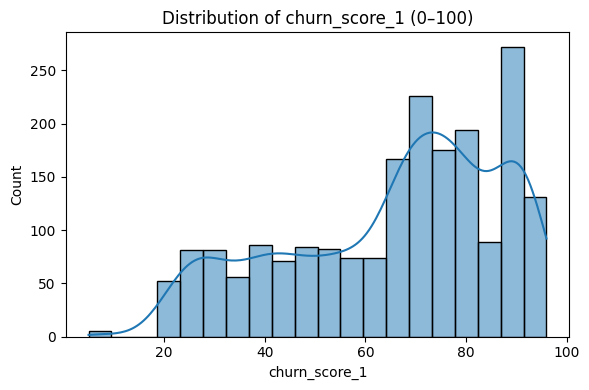

In [214]:
# ============================================================
# 5. Target definition & basic distribution (regression 0–100)
# ============================================================

target_col = 'churn_score_1'  # 0–100 score
assert target_col in df_model.columns, f'{target_col} not found in df_model columns'

y = df_model[target_col].astype(float)
X = df_model.drop(columns=[target_col])

print('Target summary:')
display(y.describe())

plt.figure(figsize=(6, 4))
sns.histplot(y, bins=20, kde=True)
plt.title('Distribution of churn_score_1 (0–100)')
plt.xlabel('churn_score_1')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [215]:
# ============================================================
# 6. Identify categorical vs numerical features
# ============================================================

cat_cols = list(X.select_dtypes(include=['object']).columns)
num_cols = list(X.select_dtypes(include=[np.number]).columns)

print('Categorical columns:', cat_cols)
print('Numeric columns:', num_cols)

Categorical columns: []
Numeric columns: ['senior_citizen', 'tenure_months', 'monthly_charges', 'total_charges', 'age', 'number_of_referrals', 'avg_monthly_gb_download', 'total_refunds', 'total_extra_data_charges', 'total_revenue', 'satisfaction_level', 'ismale', 'ispartner', 'isdependents', 'isphone_service', 'ismultiple_lines', 'isFiberOpticInternetService', 'DSLInternetService', 'isstreaming_tv', 'isstreaming_movies', 'iscontract_typeMonth-to-month', 'iscontract_typeTwo year', 'iscontract_typeOne year', 'ispaperless_billing', 'ispayment_methodElectronic check', 'ispayment_methodMailed check', 'ispayment_methodBank transfer', 'ispayment_methodCredit card', 'ismarried', 'isPromoOffer', 'isstreaming_music', 'isunlimited_data']


In [216]:
# ============================================================
# 7. Top 5 categorical features by cardinality
#    -> one-hot encode fully; remaining categorical via one-hot as well
# ============================================================

cat_nunique = X[cat_cols].nunique().sort_values(ascending=False)
print('Categorical cardinalities:')
display(cat_nunique)

top5_cat = list(cat_nunique.head(5).index)
other_cat = [c for c in cat_cols if c not in top5_cat]

print('Top 5 categorical:', top5_cat)
print('Other categorical:', other_cat)

Categorical cardinalities:


,0


Top 5 categorical: []
Other categorical: []


In [217]:
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

transformers = []
if cat_cols: # Only add 'cat' transformer if there are categorical columns
    transformers.append(('cat', ohe, cat_cols))
transformers.append(('num', 'passthrough', num_cols))

preprocessor = ColumnTransformer(
    transformers=transformers
)

# Fit-transform to get encoded design matrix (for EDA, correlation, etc.)
X_encoded = preprocessor.fit_transform(X)

# Build column names for the encoded matrix
if cat_cols:
    cat_feature_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols))
else:
    cat_feature_names = [] # If no cat_cols, no cat_feature_names

all_feature_names = cat_feature_names + num_cols

X_encoded_df = pd.DataFrame(X_encoded, columns=all_feature_names, index=X.index)
print('Encoded feature matrix shape:', X_encoded_df.shape)
X_encoded_df.head()

Encoded feature matrix shape: (2000, 32)


,senior_citizen,tenure_months,monthly_charges,total_charges,age,number_of_referrals,avg_monthly_gb_download,total_refunds,total_extra_data_charges,total_revenue,satisfaction_level,ismale,ispartner,isdependents,isphone_service,ismultiple_lines,isFiberOpticInternetService,DSLInternetService,isstreaming_tv,isstreaming_movies,iscontract_typeMonth-to-month,iscontract_typeTwo year,iscontract_typeOne year,ispaperless_billing,ispayment_methodElectronic check,ispayment_methodMailed check,ispayment_methodBank transfer,ispayment_methodCredit card,ismarried,isPromoOffer,isstreaming_music,isunlimited_data
0,0.0,26.0,19.8,457.30,63.0,0.0,0.0,0.00,0.0,1645.50,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.0,1.0,70.5,70.50,53.0,0.0,3.0,0.00,0.0,111.89,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,72.0,109.7,8129.30,42.0,7.0,3.0,0.00,0.0,9472.82,3.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
3,0.0,12.0,94.2,1046.10,53.0,0.0,24.0,7.39,120.0,1311.71,2.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,27.0,81.7,2212.55,58.0,0.0,4.0,0.00,0.0,3542.30,3.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [218]:

X_encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 32 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   senior_citizen                    2000 non-null   float64
 1   tenure_months                     2000 non-null   float64
 2   monthly_charges                   2000 non-null   float64
 3   total_charges                     2000 non-null   float64
 4   age                               2000 non-null   float64
 5   number_of_referrals               2000 non-null   float64
 6   avg_monthly_gb_download           2000 non-null   float64
 7   total_refunds                     2000 non-null   float64
 8   total_extra_data_charges          2000 non-null   float64
 9   total_revenue                     2000 non-null   float64
 10  satisfaction_level                2000 non-null   float64
 11  ismale                            2000 non-null   float64
 12  ispart

Top 20 positively correlated features with churn_score_1:


,churn_score_1
iscontract_typeMonth-to-month,0.371299
isFiberOpticInternetService,0.265814
ispayment_methodElectronic check,0.233661
ispaperless_billing,0.185153
monthly_charges,0.177774
isunlimited_data,0.162553
senior_citizen,0.124074
age,0.107952
isstreaming_movies,0.075764
avg_monthly_gb_download,0.062698


Top 20 negatively correlated features with churn_score_1:


,churn_score_1
ismultiple_lines,0.019943
isphone_service,0.002950
total_extra_data_charges,-0.010110
isPromoOffer,-0.013313
total_refunds,-0.027438
ispayment_methodMailed check,-0.084622
ispayment_methodBank transfer,-0.095426
ispayment_methodCredit card,-0.106495
DSLInternetService,-0.112557
iscontract_typeOne year,-0.139712


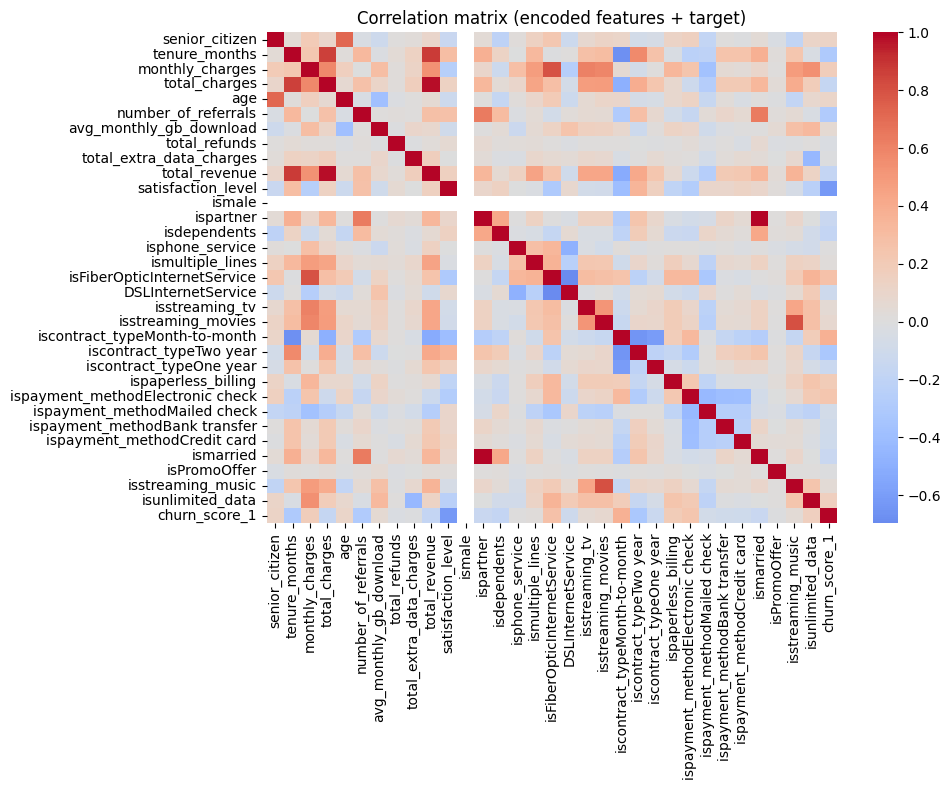

In [219]:
# ============================================================
# 9. EDA for regression: correlation matrix with target
# ============================================================

# Append target to encoded features for correlation analysis
eda_df = X_encoded_df.copy()
eda_df[target_col] = y.values

corr_matrix = eda_df.corr()
target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)

print('Top 20 positively correlated features with churn_score_1:')
display(target_corr.head(20))

print('Top 20 negatively correlated features with churn_score_1:')
display(target_corr.tail(20))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation matrix (encoded features + target)')
plt.tight_layout()
plt.show()

In [221]:
# ============================================================
# 10. Collinearity: highly correlated feature pairs
# ============================================================

threshold = 0.8  # absolute correlation threshold
corr_abs = corr_matrix.abs()

collinear_pairs = []
cols = corr_abs.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if corr_abs.iloc[i, j] > threshold:
            collinear_pairs.append((cols[i], cols[j], corr_abs.iloc[i, j]))

collinear_pairs_sorted = sorted(collinear_pairs, key=lambda x: x[2], reverse=True)

print(f'Collinear feature pairs (|corr| > {threshold}): {len(collinear_pairs_sorted)} found')
for pair in collinear_pairs_sorted[:30]:
    print(pair)

Collinear feature pairs (|corr| > 0.8): 5 found
('ispartner', 'ismarried', np.float64(1.0))
('total_charges', 'total_revenue', np.float64(0.9774098470051975))
('tenure_months', 'total_revenue', np.float64(0.8750064298462532))
('tenure_months', 'total_charges', np.float64(0.8565349650650028))
('isstreaming_movies', 'isstreaming_music', np.float64(0.8024347624398103))


In [ ]:
X_encoded_df.drop(columns=[
    #'churn_score_target',
    "total_charges",
    'total_revenue',
    'isstreaming_movies',
    'ispartner'
], inplace=True)

In [223]:
# ============================================================
# 11. Feature importance via XGBoost (using encoded features)
#      -> direct / inverse proportionality via correlation + importance
# ============================================================

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_encoded_df, y, test_size=0.2, random_state=42
)

xgb_full = XGBRegressor(
    random_state=42,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)

xgb_full.fit(X_train_full, y_train_full)

importances = xgb_full.feature_importances_
fi_df = pd.DataFrame({'feature': X_encoded_df.columns, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False)

print('Top 25 features by XGBoost importance:')
display(fi_df.head(25))

# Merge with correlation to show direction (direct vs inverse)
fi_df['corr_with_target'] = fi_df['feature'].map(target_corr)

print('Top 25 important features with correlation sign (direct vs inverse):')
display(fi_df.head(25))

Top 25 features by XGBoost importance:


,feature,importance
8,satisfaction_level,0.314042
16,iscontract_typeMonth-to-month,0.066665
13,isFiberOpticInternetService,0.063561
4,number_of_referrals,0.040790
17,iscontract_typeTwo year,0.029012
27,isunlimited_data,0.027285
20,ispayment_methodElectronic check,0.026897
19,ispaperless_billing,0.026218
26,isstreaming_music,0.026023
7,total_extra_data_charges,0.025839


Top 25 important features with correlation sign (direct vs inverse):


,feature,importance,corr_with_target
8,satisfaction_level,0.314042,-0.624952
16,iscontract_typeMonth-to-month,0.066665,0.371299
13,isFiberOpticInternetService,0.063561,0.265814
4,number_of_referrals,0.040790,-0.286988
17,iscontract_typeTwo year,0.029012,-0.322524
27,isunlimited_data,0.027285,0.162553
20,ispayment_methodElectronic check,0.026897,0.233661
19,ispaperless_billing,0.026218,0.185153
26,isstreaming_music,0.026023,0.044611
7,total_extra_data_charges,0.025839,-0.010110


In [224]:
# ============================================================
# 12. Train-test split for full pipeline (raw X + y)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded_df, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (1600, 28)
Test shape: (400, 28)


In [225]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 1600 entries, 968 to 1126
Series name: churn_score_1
Non-Null Count  Dtype  
--------------  -----  
1600 non-null   float64
dtypes: float64(1)
memory usage: 25.0 KB


In [226]:
y_train

,churn_score_1
968,75.0
240,67.0
819,31.0
692,71.0
420,77.0
...,...
1130,69.0
1294,28.0
860,75.0
1459,28.0


In [227]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1600 entries, 968 to 1126
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   senior_citizen                    1600 non-null   float64
 1   tenure_months                     1600 non-null   float64
 2   monthly_charges                   1600 non-null   float64
 3   age                               1600 non-null   float64
 4   number_of_referrals               1600 non-null   float64
 5   avg_monthly_gb_download           1600 non-null   float64
 6   total_refunds                     1600 non-null   float64
 7   total_extra_data_charges          1600 non-null   float64
 8   satisfaction_level                1600 non-null   float64
 9   ismale                            1600 non-null   float64
 10  isdependents                      1600 non-null   float64
 11  isphone_service                   1600 non-null   float64
 12  ismultipl

In [ ]:
# ============================================================
# REGRESSION MODELING
# Decision Tree Regressor + XGBoost Regressor
# Using Scikit-learn Pipeline + GridSearchCV
# ============================================================

import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ============================================================
# ASSUMPTION
# ============================================================
# You already have:
#
# X_train
# X_test
# y_train
# y_test
# preprocessor
#
# Example:
# X_train, X_test, y_train, y_test = train_test_split(...)
#
# And your preprocessor has already been created using
# ColumnTransformer / OneHotEncoder / StandardScaler, etc.


# ============================================================
# 1. DECISION TREE REGRESSOR
# ============================================================

dt_reg = DecisionTreeRegressor(
    random_state=42
)

dt_pipeline = Pipeline(steps=[
    ('model', dt_reg)
])


# Hyperparameter grid for Decision Tree
dt_param_grid = {
    'model__max_depth': [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}


# Grid Search for Decision Tree
dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)


print("=" * 70)
print("TRAINING DECISION TREE REGRESSOR")
print("=" * 70)

dt_grid.fit(X_train, y_train)


print("\nDecision Tree Best Parameters:")
print(dt_grid.best_params_)

print("\nDecision Tree Best CV MSE:")
print(-dt_grid.best_score_)


# ============================================================
# 2. XGBOOST REGRESSOR
# ============================================================

xgb_reg = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

xgb_pipeline = Pipeline(steps=[
    ('model', xgb_reg)
])


# Hyperparameter grid for XGBoost
xgb_param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}


# Grid Search for XGBoost
xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)


print("\n" + "=" * 70)
print("TRAINING XGBOOST REGRESSOR")
print("=" * 70)

xgb_grid.fit(X_train, y_train)


print("\nXGBoost Best Parameters:")
print(xgb_grid.best_params_)

print("\nXGBoost Best CV MSE:")
print(-xgb_grid.best_score_)


# ============================================================
# 3. PREDICTIONS ON TEST DATA
# ============================================================

dt_pred = dt_grid.predict(X_test)

xgb_pred = xgb_grid.predict(X_test)


# ============================================================
# 4. EVALUATION FUNCTION
# ============================================================

def evaluate_regression_model(model_name, y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("\n" + "-" * 70)
    print(model_name)
    print("-" * 70)

    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")

    return {
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }


# ============================================================
# 5. EVALUATE BOTH MODELS
# ============================================================

dt_results = evaluate_regression_model(
    "Decision Tree Regressor",
    y_test,
    dt_pred
)

xgb_results = evaluate_regression_model(
    "XGBoost Regressor",
    y_test,
    xgb_pred
)


# ============================================================
# 6. MODEL COMPARISON
# ============================================================

results = pd.DataFrame([
    dt_results,
    xgb_results
])


print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(results.to_string(index=False))


# ============================================================
# 7. IDENTIFY BEST MODEL
# ============================================================
# For MSE / RMSE / MAE:
# Lower is better.
#
# For R2:
# Higher is better.

best_model_name = results.loc[
    results['RMSE'].idxmin(),
    'Model'
]

print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(f"Best model based on Test RMSE: {best_model_name}")


# ============================================================
# 8. GET THE BEST TRAINED PIPELINE
# ============================================================

if best_model_name == "Decision Tree Regressor":
    best_model = dt_grid.best_estimator_
else:
    best_model = xgb_grid.best_estimator_


print("\nBest trained pipeline:")
print(best_model)


In [121]:
# ============================================================
# BEST MODEL - COMPLETE EVALUATION & VISUALIZATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
    median_absolute_error,
    max_error
)

# ------------------------------------------------------------
# 1. USE THE ALREADY TRAINED BEST MODEL
# ------------------------------------------------------------

# You already selected Decision Tree as the best model
best_model = dt_grid.best_estimator_

# Predictions from the already-trained model
best_pred = best_model.predict(X_test)

# Actual values
y_actual = np.asarray(y_test)
y_pred = np.asarray(best_pred)


# ------------------------------------------------------------
# 2. CALCULATE ALL IMPORTANT REGRESSION METRICS
# ------------------------------------------------------------

mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

explained_variance = explained_variance_score(y_actual, y_pred)
median_ae = median_absolute_error(y_actual, y_pred)
max_err = max_error(y_actual, y_pred)

# Mean Absolute Percentage Error
# Avoid division by zero
non_zero = y_actual != 0

if non_zero.any():
    mape = np.mean(
        np.abs(
            (y_actual[non_zero] - y_pred[non_zero])
            / y_actual[non_zero]
        )
    ) * 100
else:
    mape = np.nan


# ------------------------------------------------------------
# 3. DISPLAY METRICS
# ------------------------------------------------------------

metrics = pd.DataFrame({
    "Metric": [
        "MSE",
        "RMSE",
        "MAE",
        "R²",
        "Explained Variance",
        "Median Absolute Error",
        "Maximum Error",
        "MAPE (%)"
    ],
    "Value": [
        mse,
        rmse,
        mae,
        r2,
        explained_variance,
        median_ae,
        max_err,
        mape
    ]
})

print("=" * 70)
print("BEST MODEL - REGRESSION EVALUATION")
print("=" * 70)

print(f"\nBest Model: Decision Tree Regressor")
print(f"Best Parameters: {dt_grid.best_params_}")

print("\nMetrics:")
print(metrics.to_string(index=False))




BEST MODEL - REGRESSION EVALUATION

Best Model: Decision Tree Regressor
Best Parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}

Metrics:
               Metric     Value
                  MSE  3.047716
                 RMSE  1.745771
                  MAE  0.210402
                   R²  0.993220
   Explained Variance  0.993231
Median Absolute Error  0.000000
        Maximum Error 23.000000
             MAPE (%)  0.253423


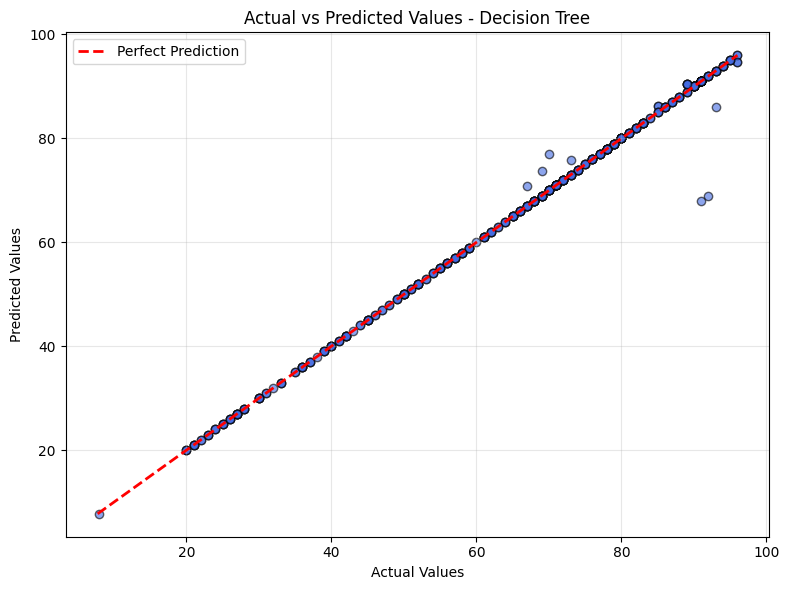

In [122]:
# ------------------------------------------------------------
# 4. CALCULATE RESIDUALS / ERRORS
# ------------------------------------------------------------

residuals = y_actual - y_pred
absolute_errors = np.abs(residuals)
squared_errors = residuals ** 2


# ------------------------------------------------------------
# 5. ACTUAL VS PREDICTED
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_actual,
    y_pred,
    alpha=0.6,
    color="royalblue",
    edgecolor="black"
)

# Perfect prediction line
min_value = min(y_actual.min(), y_pred.min())
max_value = max(y_actual.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values - Decision Tree")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


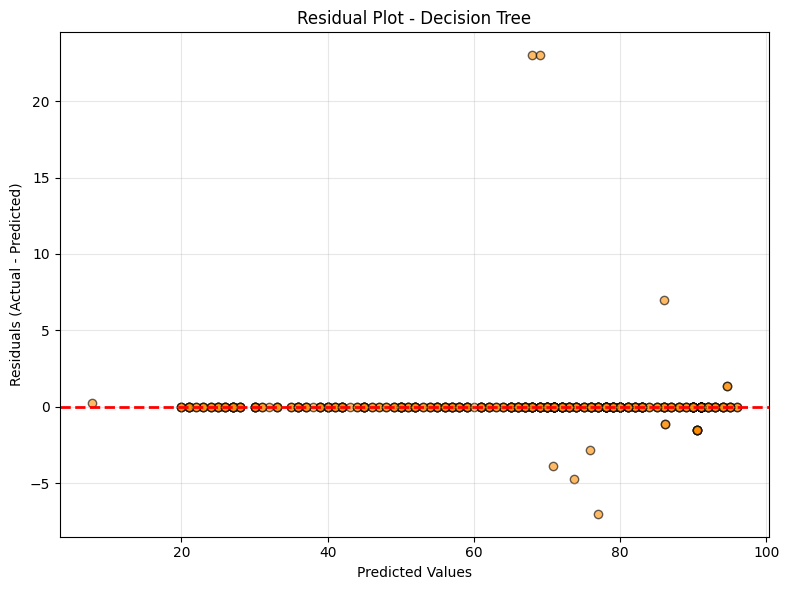

In [125]:


# ------------------------------------------------------------
# 6. RESIDUAL PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6,
    color="darkorange",
    edgecolor="black"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot - Decision Tree")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



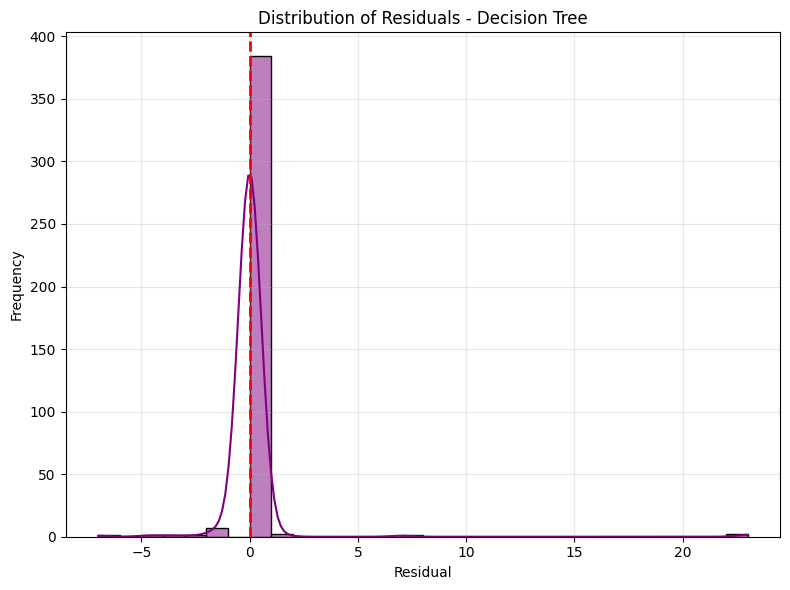

In [126]:

# ------------------------------------------------------------
# 7. RESIDUAL DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.histplot(
    residuals,
    bins=30,
    kde=True,
    color="purple"
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals - Decision Tree")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


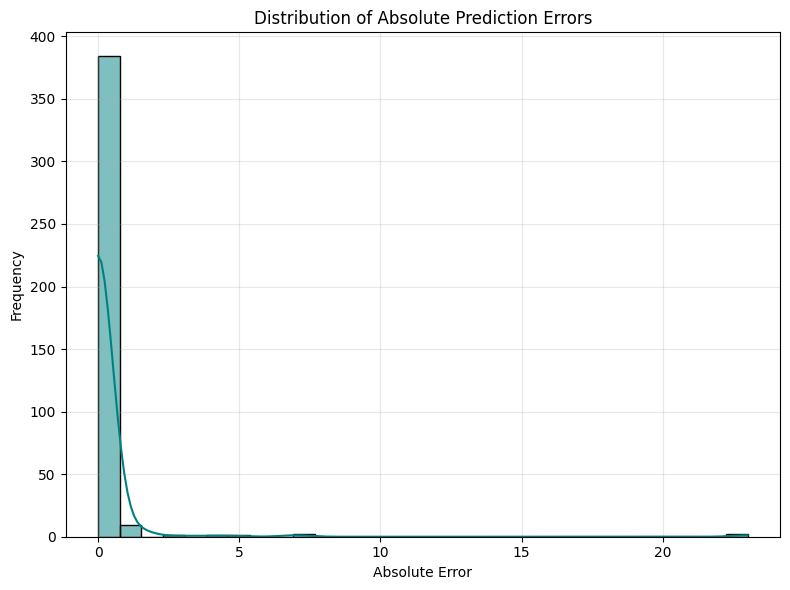

In [127]:


# ------------------------------------------------------------
# 8. ABSOLUTE ERROR DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.histplot(
    absolute_errors,
    bins=30,
    kde=True,
    color="teal"
)

plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Distribution of Absolute Prediction Errors")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

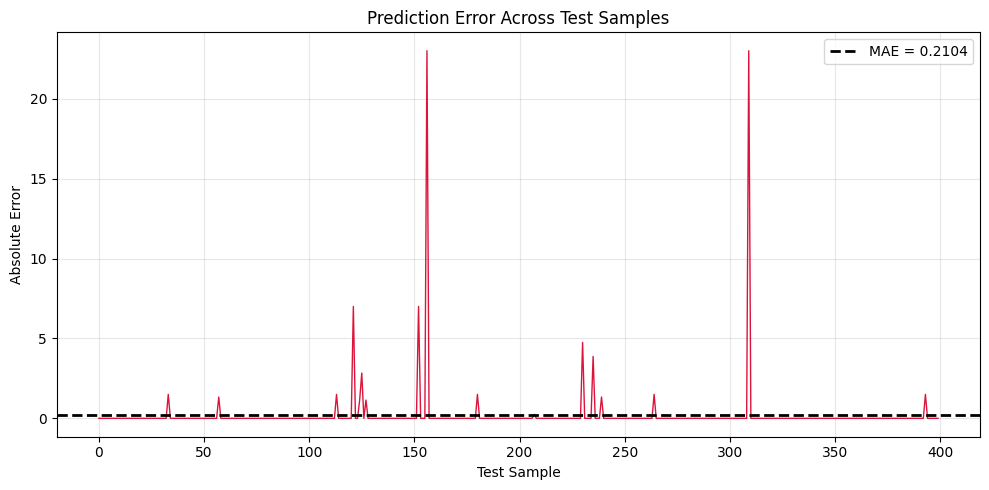

In [128]:



# ------------------------------------------------------------
# 9. ERROR BY SAMPLE
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    absolute_errors,
    color="crimson",
    linewidth=1
)

plt.axhline(
    y=mae,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"MAE = {mae:.4f}"
)

plt.xlabel("Test Sample")
plt.ylabel("Absolute Error")
plt.title("Prediction Error Across Test Samples")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


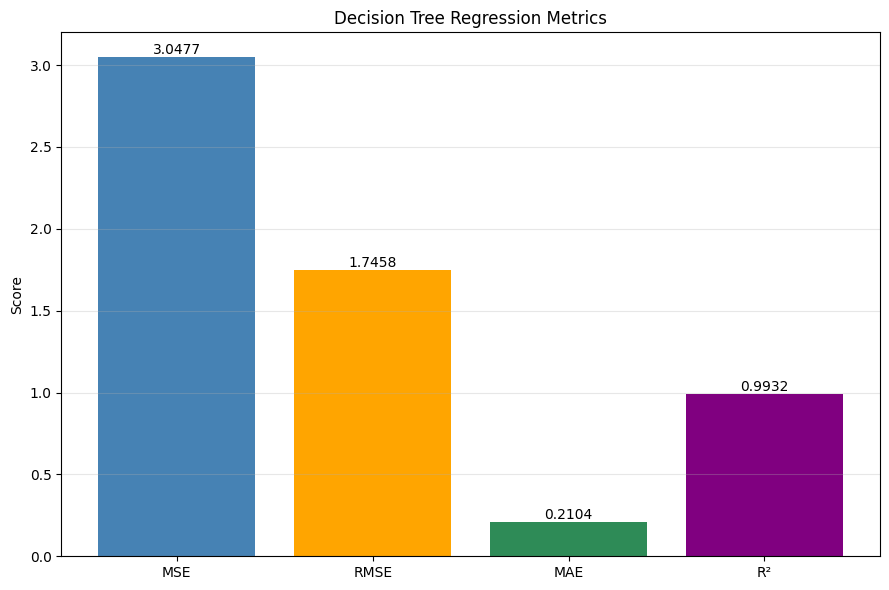

In [129]:


# ------------------------------------------------------------
# 10. METRICS BAR CHART
# ------------------------------------------------------------

metric_names = [
    "MSE",
    "RMSE",
    "MAE",
    "R²"
]

metric_values = [
    mse,
    rmse,
    mae,
    r2
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    metric_names,
    metric_values,
    color=[
        "steelblue",
        "orange",
        "seagreen",
        "purple"
    ]
)

plt.ylabel("Score")
plt.title("Decision Tree Regression Metrics")

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:


# ------------------------------------------------------------
# 11. FEATURE IMPORTANCE
# ------------------------------------------------------------

# Get the trained Decision Tree from the pipeline
tree_model = best_model.named_steps["model"]

# Get transformed feature names
preprocessor_fitted = best_model.named_steps["preprocess"]

try:
    feature_names = preprocessor_fitted.get_feature_names_out()

    importances = tree_model.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    feature_importance_df = (
        feature_importance_df
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    print("\n" + "=" * 70)
    print("TOP 20 FEATURE IMPORTANCES")
    print("=" * 70)

    print(
        feature_importance_df.head(20).to_string(index=False)
    )

    # Plot top 20 features
    top_features = feature_importance_df.head(20).sort_values(
        "Importance",
        ascending=True
    )

    plt.figure(figsize=(10, 8))

    plt.barh(
        top_features["Feature"],
        top_features["Importance"],
        color="steelblue"
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title("Top 20 Feature Importances - Decision Tree")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print("\nFeature importance could not be extracted.")
    print("Reason:", e)

In [131]:



# ------------------------------------------------------------
# 12. ACTUAL VS PREDICTED TABLE
# ------------------------------------------------------------

prediction_results = pd.DataFrame({
    "Actual": y_actual,
    "Predicted": y_pred,
    "Residual": residuals,
    "Absolute_Error": absolute_errors,
    "Squared_Error": squared_errors
})

print("\n" + "=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)

print(prediction_results.head(20).to_string(index=False))



SAMPLE PREDICTIONS
 Actual  Predicted  Residual  Absolute_Error  Squared_Error
   51.0       51.0       0.0             0.0            0.0
   47.0       47.0       0.0             0.0            0.0
   69.0       69.0       0.0             0.0            0.0
   72.0       72.0       0.0             0.0            0.0
   69.0       69.0       0.0             0.0            0.0
   74.0       74.0       0.0             0.0            0.0
   72.0       72.0       0.0             0.0            0.0
   91.0       91.0       0.0             0.0            0.0
   42.0       42.0       0.0             0.0            0.0
   80.0       80.0       0.0             0.0            0.0
   25.0       25.0       0.0             0.0            0.0
   95.0       95.0       0.0             0.0            0.0
   86.0       86.0       0.0             0.0            0.0
   86.0       86.0       0.0             0.0            0.0
   66.0       66.0       0.0             0.0            0.0
   78.0       78.0  

In [132]:


# ------------------------------------------------------------
# 13. BEST / WORST PREDICTIONS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BEST PREDICTIONS")
print("=" * 70)

print(
    prediction_results
    .sort_values("Absolute_Error")
    .head(10)
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("WORST PREDICTIONS")
print("=" * 70)

print(
    prediction_results
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
    .to_string(index=False)
)


BEST PREDICTIONS
 Actual  Predicted  Residual  Absolute_Error  Squared_Error
   75.0       75.0       0.0             0.0            0.0
   68.0       68.0       0.0             0.0            0.0
   70.0       70.0       0.0             0.0            0.0
   26.0       26.0       0.0             0.0            0.0
   91.0       91.0       0.0             0.0            0.0
   45.0       45.0       0.0             0.0            0.0
   94.0       94.0       0.0             0.0            0.0
   20.0       20.0       0.0             0.0            0.0
   90.0       90.0       0.0             0.0            0.0
   39.0       39.0       0.0             0.0            0.0

WORST PREDICTIONS
 Actual  Predicted  Residual  Absolute_Error  Squared_Error
   91.0  68.000000 23.000000       23.000000     529.000000
   92.0  69.000000 23.000000       23.000000     529.000000
   70.0  77.000000 -7.000000        7.000000      49.000000
   93.0  86.000000  7.000000        7.000000      49.000000
   

Test MAE: 13.024663038253784
Test MSE: 257.9114336218126
Test RMSE: 16.05962121663561
Test R^2: 0.4262785319619833


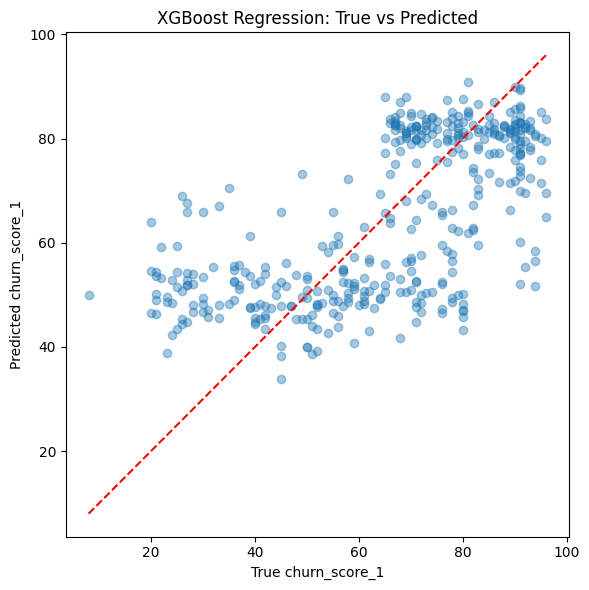

In [38]:
# # ============================================================
# # 13. Full modeling pipeline: preprocessing + XGBoost + tuning
# # ============================================================

# # Re-identify categorical and numerical columns based on the current state of X_train
# cat_cols = list(X_train.select_dtypes(include=['object']).columns)
# num_cols = list(X_train.select_dtypes(include=[np.number]).columns)

# ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# transformers = []
# if cat_cols: # Only add 'cat' transformer if there are categorical columns
#     transformers.append(('cat', ohe, cat_cols))
# transformers.append(('num', 'passthrough', num_cols))

# preprocessor = ColumnTransformer(
#     transformers=transformers
# )

# xgb_reg = XGBRegressor(
#     objective='reg:squarederror',
#     random_state=42
# )

# model_pipeline = Pipeline(steps=[
#     ('preprocess', preprocessor),
#     ('xgb', xgb_reg)
# ])

# param_grid = {
#     'xgb__n_estimators': [200, 400],
#     'xgb__max_depth': [4, 6, 8],
#     'xgb__learning_rate': [0.05, 0.1],
#     'xgb__subsample': [0.8, 1.0],
#     'xgb__colsample_bytree': [0.8, 1.0]
# }

# grid_search = GridSearchCV(
#     estimator=model_pipeline,
#     param_grid=param_grid,
#     cv=3,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# grid_search.fit(X_train, y_train)

# print('Best params:', grid_search.best_params_)
# print('Best CV score (neg MSE):', grid_search.best_score_)
# # ============================================================
# # 14. Final evaluation on test set
# # ============================================================

# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test)

# mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)
# rmse = np.sqrt(mse)
# r2 = r2_score(y_test, y_pred)

# print('Test MAE:', mae)
# print('Test MSE:', mse)
# print('Test RMSE:', rmse)
# print('Test R^2:', r2)

# plt.figure(figsize=(6, 6))
# plt.scatter(y_test, y_pred, alpha=0.4)
# plt.xlabel('True churn_score_1')
# plt.ylabel('Predicted churn_score_1')
# plt.title('XGBoost Regression: True vs Predicted')
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
# plt.tight_layout()
# plt.show()